In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#Charger du fichcier Clien_assurance  deja netoye dans le TP 0
df = pd.read_csv("fichier_netoyee.csv")

In [3]:
df.head()  #C'est ok le fichier a ete bien charger 

,id_client,nom,age,type_contrat,date_contrat,region,prime,nb_sinistres,montant_sinistres
0,100,Client_100,35.000000,auto,2022-04-23,Savanes,324.63,3,810.05
1,298,Client_298,57.000000,moto,2020-04-05,Plateaux,172.37,0,0.00
2,90,Client_90,65.000000,habitation,2020-08-03,Plateaux,179.38,1,612.00
3,31,Client_31,45.692833,auto,2021-02-05,Savanes,245.67,0,0.00
4,236,Client_236,69.000000,habitation,2021-12-23,Maritime,130.21,1,567.57


# (1) -Comment l'age des  client est - il repartie  dans le portfeuille (distribution)

In [4]:
#        Le   reflexe c'est de visualiser voir en utilisant la fonction hist(Histogramme pour visualiser la repartition ou distribution des ages
#       de la bibliotetheque matplotli ou histplot de seaborn, ici on va utiliser les methodes de visualisation

In [5]:
#                                        AVEC MATPLOTLIB 

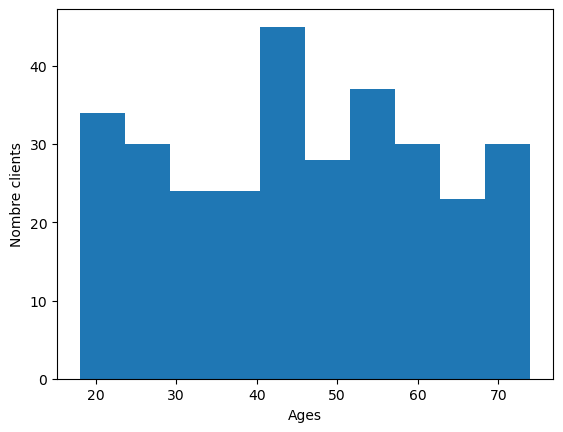

In [6]:
plt.hist(df["age"], bins = 10)
plt.xlabel("Ages")
plt.ylabel("Nombre clients")
plt.show()

In [7]:
##                                               ANALYSE GRAPHIQUE
#                    lES clients QUI ON LEUR AGES ENTRE [40 , 48] SON NOMBREUX DANS NOTRE DATASET

In [8]:
#                                   ==================================================================
# #                                       UTILISATION DE HISTPLOT DE LA BIBILOTHEQUE SEABORN
#                                   ==============================================================

Text(0, 0.5, 'Nombre clients')

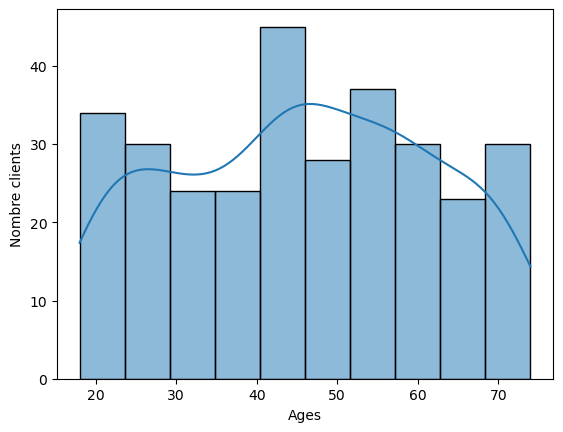

In [9]:
sns.histplot(df["age"], kde = True)
plt.xlabel("Ages")
plt.ylabel("Nombre clients")

In [10]:
 ## Plus claire on vois que le nombre de personnes qui on leur ages comprises entre [40, 45] son plus nombreux

# (2) Existe-t-il une relation entre l'age et le montant de la prime ?

In [11]:
# Pour repondre a cettte question la premiere chose que je fais , je vasi visua;liser la relation entre les deu variables age et prime , en utilisant les nuages de points , soit :
#      -scatter avec matplotlib
#      -scatterplot avec seaborn 
# Mais bon je vais tester et visualiser avec les deux methode et icnterpreter

In [12]:
# #              ==========================================================
#                       scatter de MATPLOTLIB
#                     ===============================================

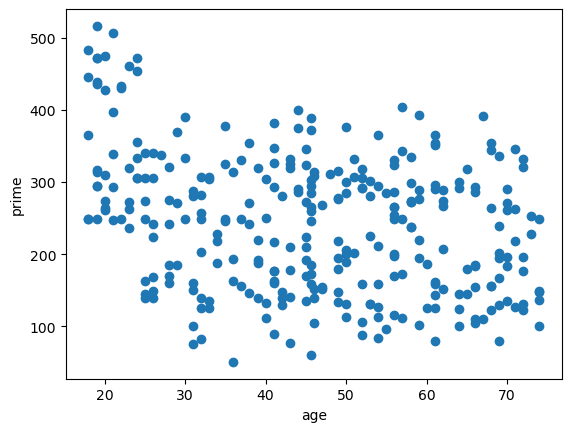

In [13]:
plt.scatter(df["age"], df["prime"])
plt.xlabel("age")
plt.ylabel("prime")
plt.show()

In [14]:
# La reamarque d'apres les nuages de point :
#     age = petit ==> prime =grands

#         En conclusions la relations d'apres cette nuages de points les primes des jeunes on 
#         tendances a deppasser celle des vieu surtocut ceux qui socn entre 19 a 25 ans

In [15]:
             #     ===============================================
             #     Avec scatterplot de SEABORN 
             # ===============================================

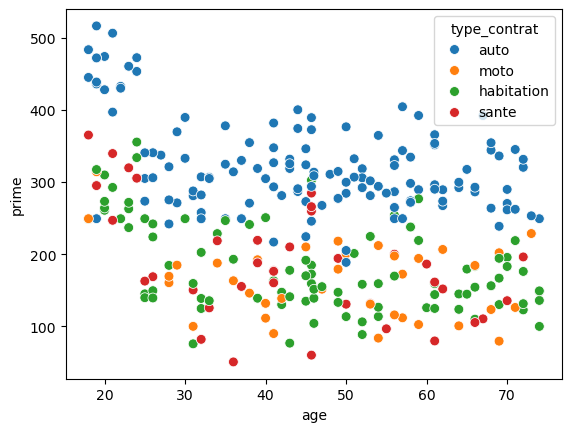

In [16]:
sns.scatterplot(data = df, x= "age", y= "prime", hue = "type_contrat", s= 50)
## s=size permet d'ajoutet la tailles des nuages de points
plt.show()

In [17]:
## L'analyse avec les differentes types de contrat comfirment ce que j'ai dit en dessus plus l'age est fpetit , la personne a droit a beacoup de prime 

In [18]:
#                    Bon pour conclure je ne peut pas baser seulement sur mes hypothese et mon analyse visuels,je doit vraimment calculer voir s'il y'a vraimment 
#                    une relaticon entre ces 2 variable (age et primes)

                                  #CORRELATION
#                Sur ceux je vais calculer la correlation entre ces deux variables poyur verifier ,mes hypotheses et conclure

In [19]:
relation  =df["age"].corr(df["prime"])
print("                         -------------------------------------------------------")
print(f"La correlation entre age et prime =  {relation }")
print("                         --------------------------------------------------- ")

                         -------------------------------------------------------
La correlation entre age et prime =  -0.3223752897425862
                         --------------------------------------------------- 


###            **CONCLUSION :**
####  on trouve ***r= -0.32*** appartenant : *[-0.4, -0.2]*, Donc une correlation faible a moderee

# (3) La prime moyenne varie- elle selon quelle type de contrat ?

<Axes: xlabel='type_contrat', ylabel='prime'>

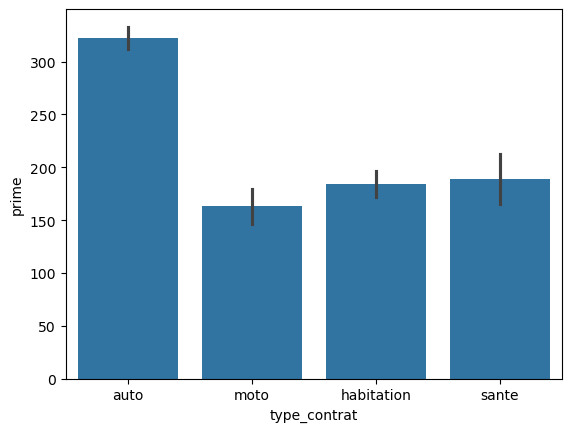

In [20]:
sns.barplot(data = df , x= "type_contrat", y = "prime")

In [21]:
# La prime est beaucou plus elevee pour les cliens en auto 

# (4) Quelle type de contrat est le plus represente dans le portefeuille

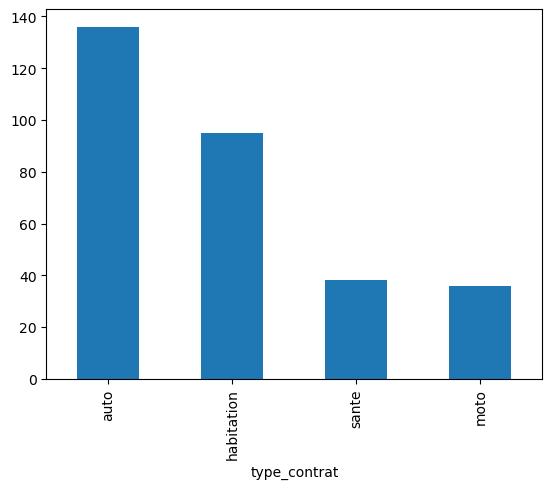

In [22]:
df["type_contrat"].value_counts().plot(kind = "bar")
plt.show()

In [23]:
# Le type de contrat le plus represente dans le portefeuille est le contrat pour l'automobile "auto"

# (5) Le nombre sinistre varie-t-elle selon la tranche d'age ?

In [24]:
# Cela revient simplement a voir s'il y'a une correlation en le nombre sinistre et l'age

<Axes: xlabel='age', ylabel='nb_sinistres'>

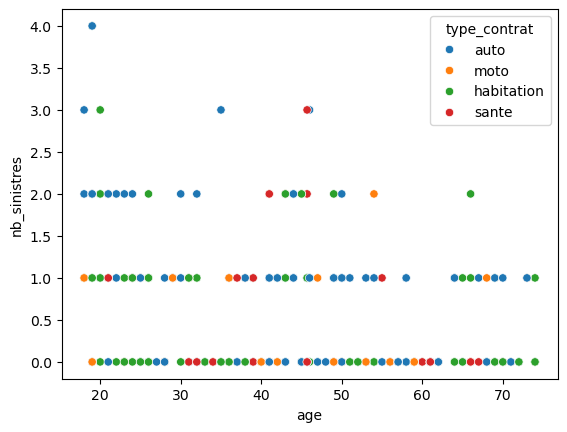

In [25]:
sns.scatterplot( data = df , x= "age" ,y= "nb_sinistres", hue = "type_contrat")

In [26]:
r= df["age"].corr(df["nb_sinistres"])
r #Correlation 

np.float64(-0.36159317911312544)

In [27]:
 #                r = -0, 36 il y'a une correlation FAIBLE MODEREE

# (6) Y'a-t-il des primes anormalement hautes ou basses (outliers)? Pour quelle type de contrat 

{'whiskers': [<matplotlib.lines.Line2D at 0x1ff197e4b90>,
 'caps': [<matplotlib.lines.Line2D at 0x1ff197e4910>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ff19621810>],
 'medians': [<matplotlib.lines.Line2D at 0x1ff197e4690>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ff197cdf90>],
 'means': []}

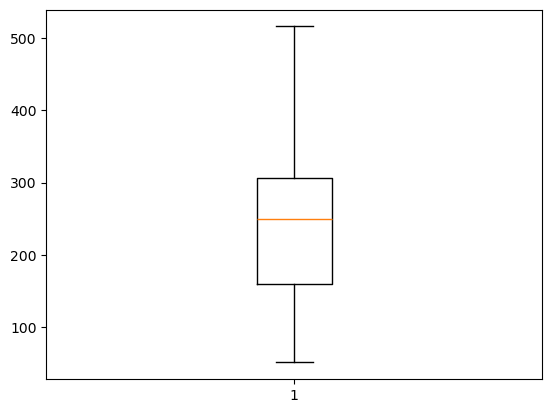

In [28]:
                           # AVEC MATPLOTLIB (IMPOSSIBLE DE SAVOIR LE TYPE DE CONTRAT CAR IL DONNE DE FACON GENERAL)?

plt.boxplot(df["prime"].dropna())

<Axes: xlabel='type_contrat', ylabel='prime'>

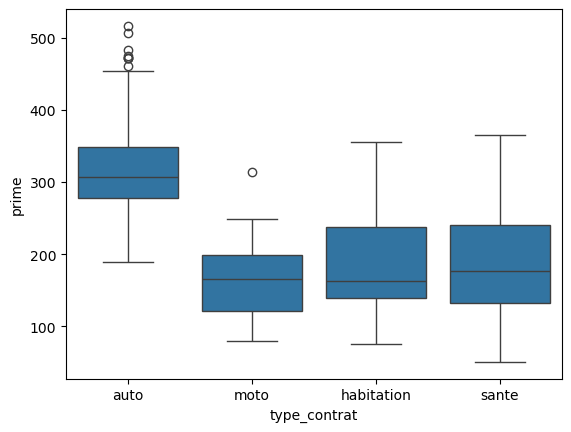

In [29]:
                        # AVEC SEABORN EN UTILISANT AUSSSI BOXPLOT AVEC PRECISIONS

sns.boxplot(data = df , x="type_contrat", y= "prime")

In [30]:
# Les primes anormalement haute se trouve pour les clients en aut

# (7) Les valeurs numeriques les plus correlee entre elles (ags, primes, nb_sinistre, montant_sinistres)

In [31]:
#Pour les relations utilisons la fonction pairplot de seaborn 

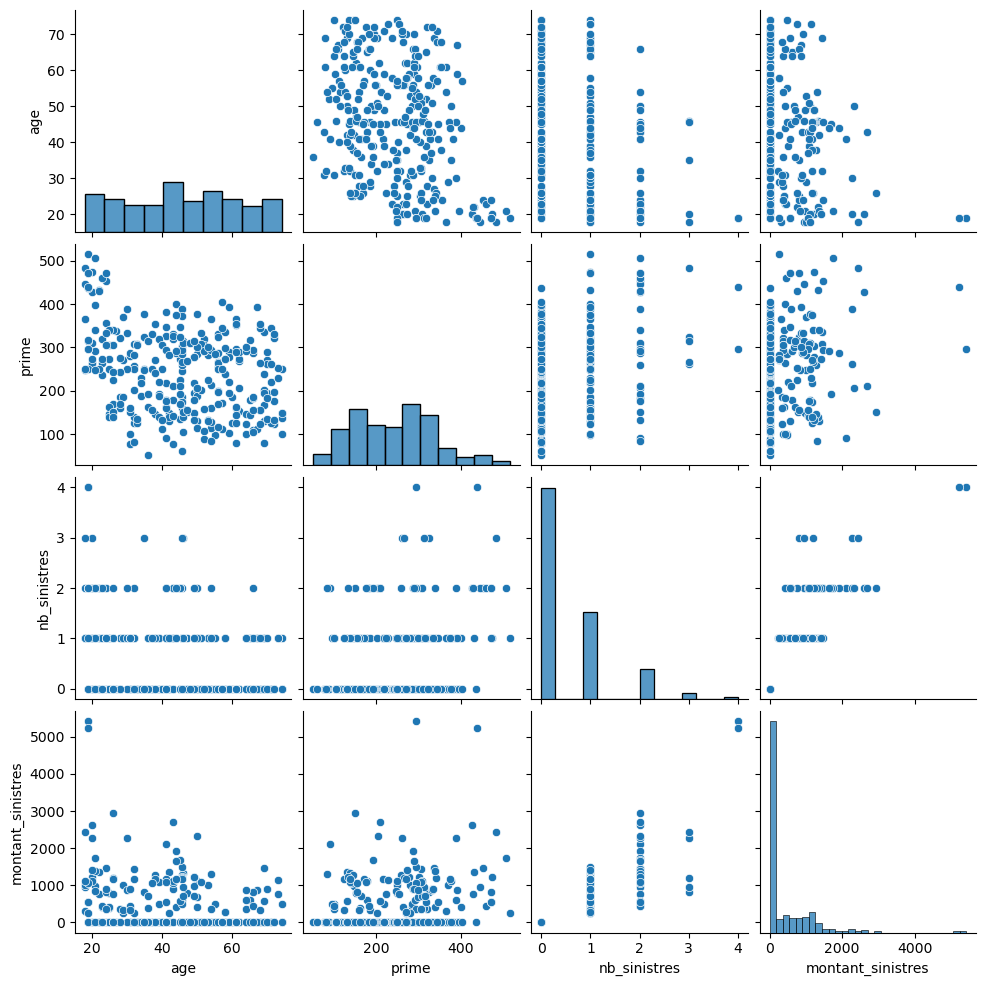

In [32]:
sns.pairplot(df[["age", "prime", "nb_sinistres", "montant_sinistres"]])

# Calcul des correlation de touts les variables par valeur calcul

<Axes: >

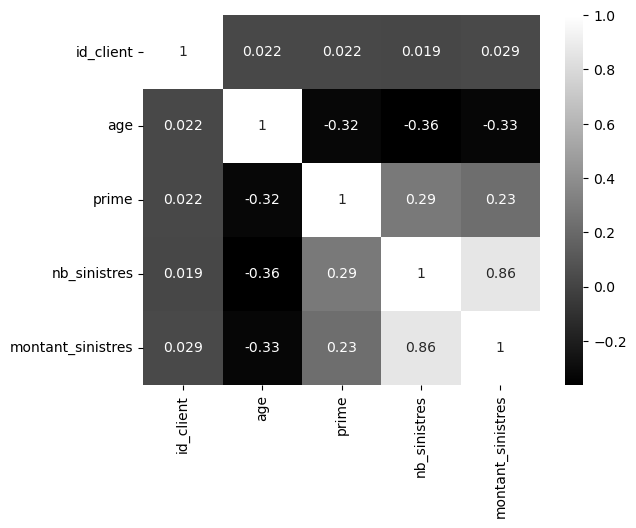

In [33]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap = "grey")